# Iris Machine Learning Pipeline

Made by Aney Kanji

This Python Notebook explores the Iris Dataset and aims to prepare a model used for the React Dashboard.

Note that a lot of the code in this notebook is for experimentation purposes and maybe a little messy. Some of the code was referenced using the documentation here:

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html

## Imports

In [45]:
# imports
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

In [46]:
# this is just to prep the output folders so I can later update the backend for the website
artifact_dir = Path("artifacts")
figure_dir = Path("figures")
artifact_dir.mkdir(exist_ok=True)
figure_dir.mkdir(exist_ok=True)

FileNotFoundError: [Errno 2] No such file or directory: 'artifacts'

## Load the Dataset

In [ ]:
# load iris
iris = load_iris()

feature_names = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

target_names = [
    "setosa",
    "versicolor",
    "virginica"
]

df = pd.DataFrame(iris.data, columns=feature_names)

df["target"] = iris.target
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
# summary of the dataset
summary = {
    "rows": int(df.shape[0]),
    "features": feature_names,
    "classes": target_names,
    "class_counts": df["species"].value_counts().to_dict(),
    "feature_summary": df[feature_names].describe().to_dict()
}

In [ ]:
summary

{'rows': 150,
 'features': ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
 'classes': ['setosa', 'versicolor', 'virginica'],
 'class_counts': {'setosa': 50, 'versicolor': 50, 'virginica': 50},
 'feature_summary': {'sepal_length': {'count': 150.0,
   'mean': 5.843333333333334,
   'std': 0.828066127977863,
   'min': 4.3,
   '25%': 5.1,
   '50%': 5.8,
   '75%': 6.4,
   'max': 7.9},
  'sepal_width': {'count': 150.0,
   'mean': 3.0573333333333337,
   'std': 0.4358662849366982,
   'min': 2.0,
   '25%': 2.8,
   '50%': 3.0,
   '75%': 3.3,
   'max': 4.4},
  'petal_length': {'count': 150.0,
   'mean': 3.7580000000000005,
   'std': 1.7652982332594662,
   'min': 1.0,
   '25%': 1.6,
   '50%': 4.35,
   '75%': 5.1,
   'max': 6.9},
  'petal_width': {'count': 150.0,
   'mean': 1.1993333333333336,
   'std': 0.7622376689603465,
   'min': 0.1,
   '25%': 0.3,
   '50%': 1.3,
   '75%': 1.8,
   'max': 2.5}}}

## Exploring Feature Patterns and Class Balance

In [ ]:
# checking class balance
class_counts = df["species"].value_counts().sort_index()

In [ ]:
class_counts

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

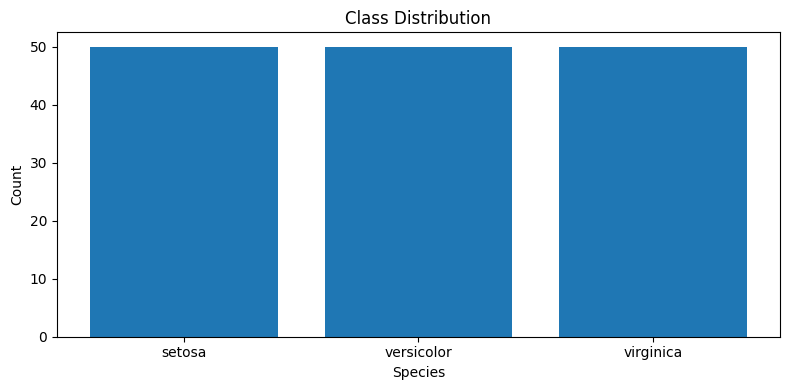

In [ ]:
# plot for class balance
plt.figure(figsize=(8, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(figure_dir / "class_distribution.png")
plt.show()

In [ ]:
# feature summary by species
feature_summary_by_species = df.groupby("species")[feature_names].mean()

In [ ]:
feature_summary_by_species

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


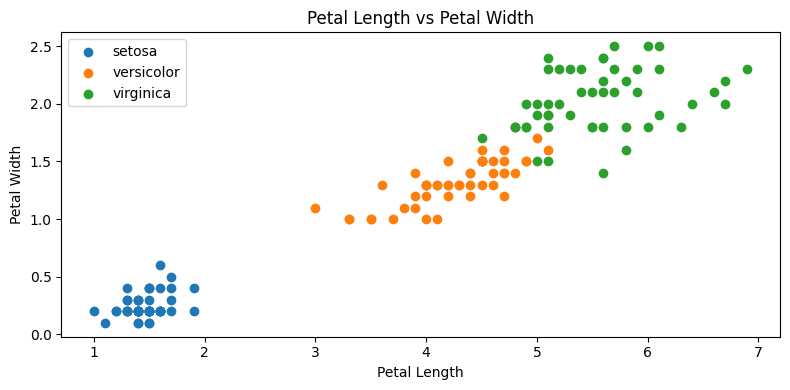

In [ ]:
# scatter plot for best visual pair
plt.figure(figsize=(8, 4))
for species in target_names:
    subset = df[df["species"] == species]
    plt.scatter(subset["petal_length"], subset["petal_width"], label=species)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / "petal_scatter.png")
plt.show()

In [ ]:
# correlation matrix
corr = df[feature_names].corr()

In [ ]:
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


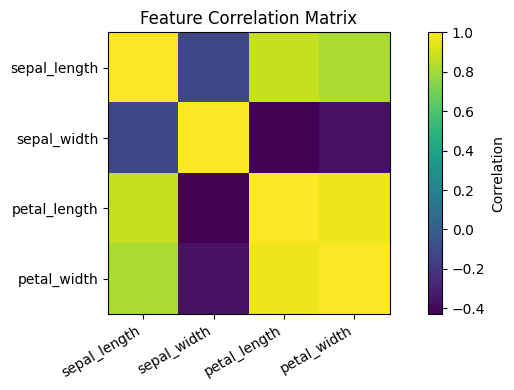

In [ ]:
# saving the correlation matrix as a simple heatmap
plt.figure(figsize=(8, 4))
plt.imshow(corr.values)
plt.xticks(range(len(feature_names)), feature_names, rotation=30, ha="right")
plt.yticks(range(len(feature_names)), feature_names)
plt.colorbar(label="Correlation")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(figure_dir / "correlation_matrix.png")
plt.show()

## Spliting the Data

Since the dataset is already balanced across the three species, oversampling is not needed.

In [ ]:
# create train test split
# no validation set is needed deep learning would be overkill for this dataset
# using a 80/20 split for training and testing
X = df[feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape

((120, 4), (30, 4))

## Comparing Models

In [ ]:
# Functions for the Models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [ ]:
# cross validation model comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    rows.append({
        "model": name,
        "accuracy": scores.mean()
    })
comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values("accuracy", ascending=False)
comparison_df = comparison_df.reset_index(drop=True)

In [ ]:
comparison_df

,model,accuracy
0,SVM,0.966667
1,Logistic Regression,0.958333
2,KNN,0.958333
3,Random Forest,0.950000


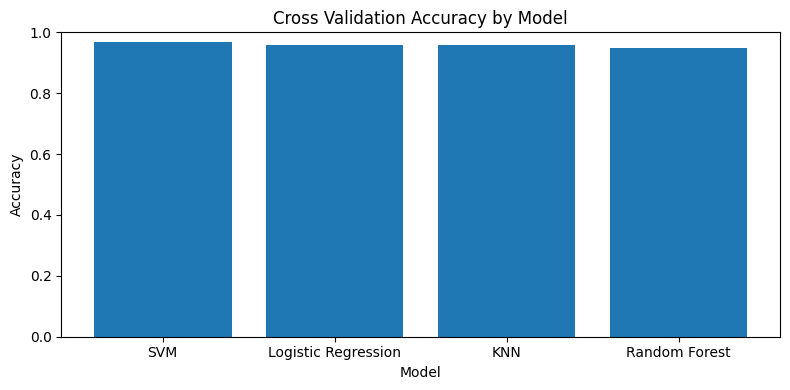

In [ ]:
# saving the model comparison plot
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["accuracy"])
plt.title("Cross Validation Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks()
plt.tight_layout()
plt.savefig(figure_dir / "model_comparison.png")
plt.show()

## Training and Evaluating the Final Model

In [ ]:
# select best model and fit on training data
best_model_name = comparison_df.loc[0, "model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [ ]:
best_model_name

'SVM'

In [ ]:
# Test Set on the Final Model
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

final_metrics = {
    "best_model": best_model_name,
    "accuracy": float(accuracy),
    "precision_macro": float(precision),
    "recall_macro": float(recall),
    "f1_macro": float(f1)
}

In [ ]:
final_metrics

{'best_model': 'SVM',
 'accuracy': 0.9666666666666667,
 'precision_macro': 0.9696969696969697,
 'recall_macro': 0.9666666666666667,
 'f1_macro': 0.9665831244778612}

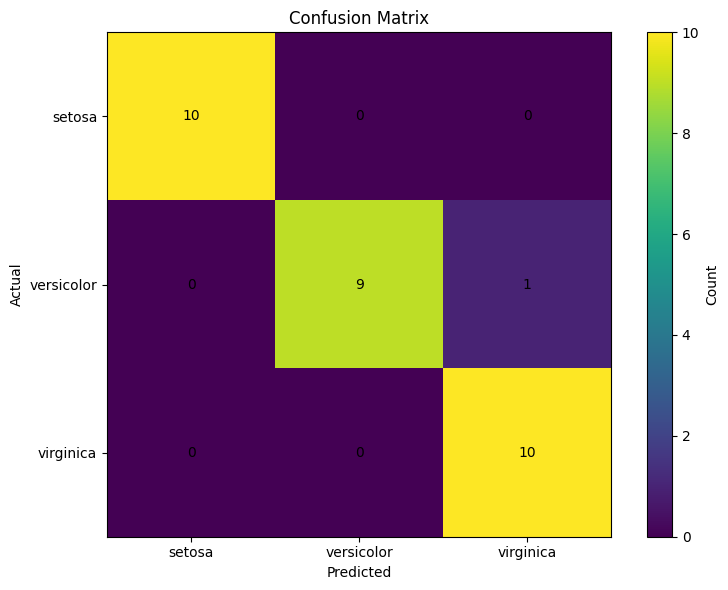

In [ ]:
# Confusion Matrix Plot
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.xticks(range(len(target_names)), target_names)
plt.yticks(range(len(target_names)), target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.colorbar(label="Count")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(figure_dir / "confusion_matrix.png")
plt.show()

## Feature Importance Analysis and PCA Visualization

In [ ]:
# Shows the feature importance of the Random Forest Model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance").reset_index(drop=True)

In [ ]:
importance_df

,feature,importance
0,sepal_width,0.017885
1,sepal_length,0.115873
2,petal_width,0.412449
3,petal_length,0.453793


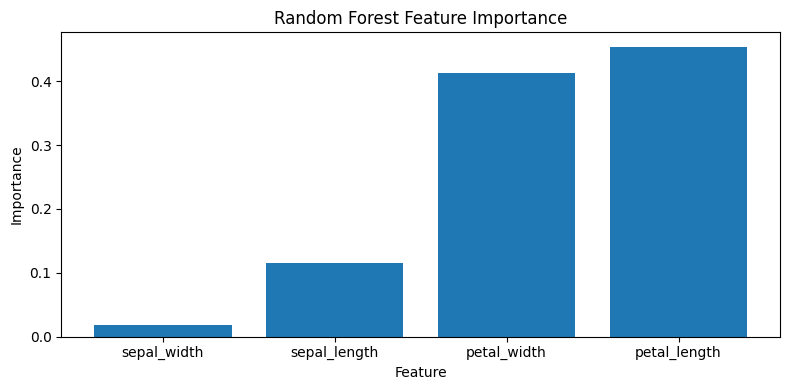

In [ ]:
# Saving the Feature Importance Plot
plt.figure(figsize=(8, 4))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks()
plt.tight_layout()
plt.savefig(figure_dir / "feature_importance.png")
plt.show()

In [ ]:
# PCA Projection for Visualization
scaled_features = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
pca_values = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame({
    "pc1": pca_values[:, 0],
    "pc2": pca_values[:, 1],
    "target": y,
    "species": df["species"]
})

pca_df.head()

,pc1,pc2,target,species
0,-2.264703,0.480027,0,setosa
1,-2.080961,-0.674134,0,setosa
2,-2.364229,-0.341908,0,setosa
3,-2.299384,-0.597395,0,setosa
4,-2.389842,0.646835,0,setosa


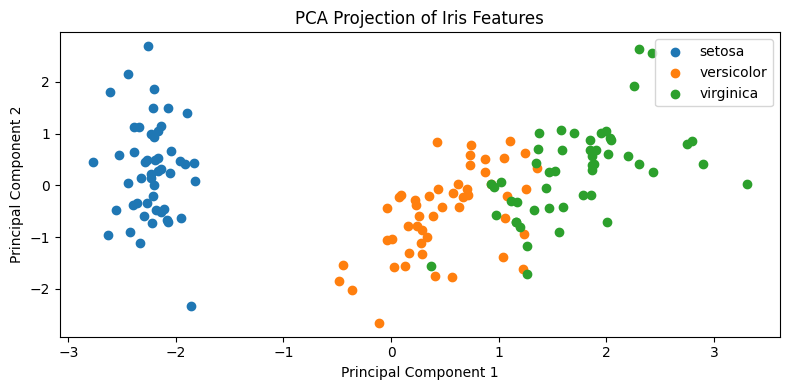

In [ ]:
# Saving the PCA Projection Plot
plt.figure(figsize=(8, 4))
for species in target_names:
    subset = pca_df[pca_df["species"] == species]
    plt.scatter(subset["pc1"], subset["pc2"], label=species)

plt.title("PCA Projection of Iris Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(figure_dir / "pca_projection.png")
plt.show()

## Exporting Artifacts

In [ ]:
# helper for json export
def write_json(path, data):
    with open(path, "w") as file:
        json.dump(data, file, indent=2)

In [ ]:
# prepare dashboard json files
model_comparison = comparison_df.to_dict(orient="records")
feature_importance = importance_df.to_dict(orient="records")
confusion_matrix_data = {
    "labels": target_names,
    "matrix": cm.tolist()
}

sample_predictions = []
for index, row_index in enumerate(X_test.index):
    probabilities = {
        target_names[class_index]: float(y_prob[index][class_index])
        for class_index in range(len(target_names))
    }
    sample_predictions.append({
        "input": X_test.loc[row_index].to_dict(),
        "actual": target_names[int(y_test.loc[row_index])],
        "predicted": target_names[int(y_pred[index])],
        "probabilities": probabilities
    })

pca_projection = pca_df.to_dict(orient="records")

In [ ]:
# export json artifacts
write_json(artifact_dir / "dataset_summary.json", summary)
write_json(artifact_dir / "model_comparison.json", model_comparison)
write_json(artifact_dir / "metrics.json", final_metrics)
write_json(artifact_dir / "confusion_matrix.json", confusion_matrix_data)
write_json(artifact_dir / "classification_report.json", report)
write_json(artifact_dir / "feature_importance.json", feature_importance)
write_json(artifact_dir / "sample_predictions.json", sample_predictions)
write_json(artifact_dir / "pca_projection.json", pca_projection)

joblib.dump(best_model, artifact_dir / "best_model.joblib")

list(artifact_dir.iterdir())

[PosixPath('artifacts/metrics.json'),
 PosixPath('artifacts/dataset_summary.json'),
 PosixPath('artifacts/confusion_matrix.json'),
 PosixPath('artifacts/best_model.joblib'),
 PosixPath('artifacts/sample_predictions.json'),
 PosixPath('artifacts/feature_importance.json'),
 PosixPath('artifacts/model_comparison.json'),
 PosixPath('artifacts/pca_projection.json'),
 PosixPath('artifacts/classification_report.json')]

## Test One Prediction

In [ ]:
# quick prediction check
loaded_model = joblib.load(artifact_dir / "best_model.joblib")
example = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=feature_names)
example_prediction = loaded_model.predict(example)[0]
example_probability = loaded_model.predict_proba(example)[0]

{
    "prediction": target_names[int(example_prediction)],
    "probabilities": {
        target_names[index]: float(example_probability[index])
        for index in range(len(target_names))
    }
}

{'prediction': 'setosa',
 'probabilities': {'setosa': 0.9722797537042359,
  'versicolor': 0.015287252177163368,
  'virginica': 0.012432994118600667}}